In [13]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigh

import os
import pickle

from qiskit import transpile
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import SparsePauliOp
from qiskit.quantum_info.operators import Operator
from qiskit_aer import AerSimulator
from qiskit.circuit import QuantumCircuit

from algo.utils_qiskit import find_pauli_indices
from utils import hamiltonian_to_matrix
from algo.utils_qiskit import process_hamiltonian_Zs
from algo.utils_qiskit import optimal_interp_points
from check_utils import interp_matrix

In [14]:
# num_q = 4 # N # IMPORTANT

# # Generate a random complex matrix
# A = np.random.rand(2**num_q, 2**num_q) + 1j * np.random.rand(2**num_q, 2**num_q)
# # Make it Hermitian
# Hmat = (A + A.conj().T) / 2

In [15]:
num_q = 12 # N # IMPORTANT

Delta = 0.5 # IMPORTANT
List_1 = []
op = ""
op = "X"
for k in range(num_q-2):
    op += "I"
op += "X"
List_1.append(op)
for i in range(num_q-1):
    op = ""
    for k in range(i):
        op += "I"
    op += "XX"
    for k in range(i+1,num_q-1):
        op += "I"
    List_1.append(op)
List_1.reverse()
H1 = SparsePauliOp(List_1, np.ones(num_q))

List_2 = []
op = "Y"
for k in range(num_q-2):
    op += "I"
op += "Y"
List_2.append(op)
for i in range(num_q-1):
    op = ""
    for k in range(i):
        op += "I"
    op += "YY"
    for k in range(i+1,num_q-1):
        op += "I"
    List_2.append(op)
List_2.reverse()
H2 = SparsePauliOp(List_2, np.ones(num_q))

H_first = SparsePauliOp.sum([H1,H2])

List_3 = []
op = "Z"
for k in range(num_q-2):
    op += "I"
op += "Z"
List_3.append(op)  
for i in range(num_q-1):
    op = ""
    for k in range(i):
        op += "I"
    op += "ZZ"
    for k in range(i+1,num_q-1):
        op += "I"
    List_3.append(op)

List_3.reverse()    
H_second = SparsePauliOp(List_3, Delta*np.ones(num_q))

# set H = H1 + H2
H = SparsePauliOp.sum([H_first,H_second])
Hmat = Operator(H)
Hmat = Hmat.data # This is the matrix representation of the Hamiltonian

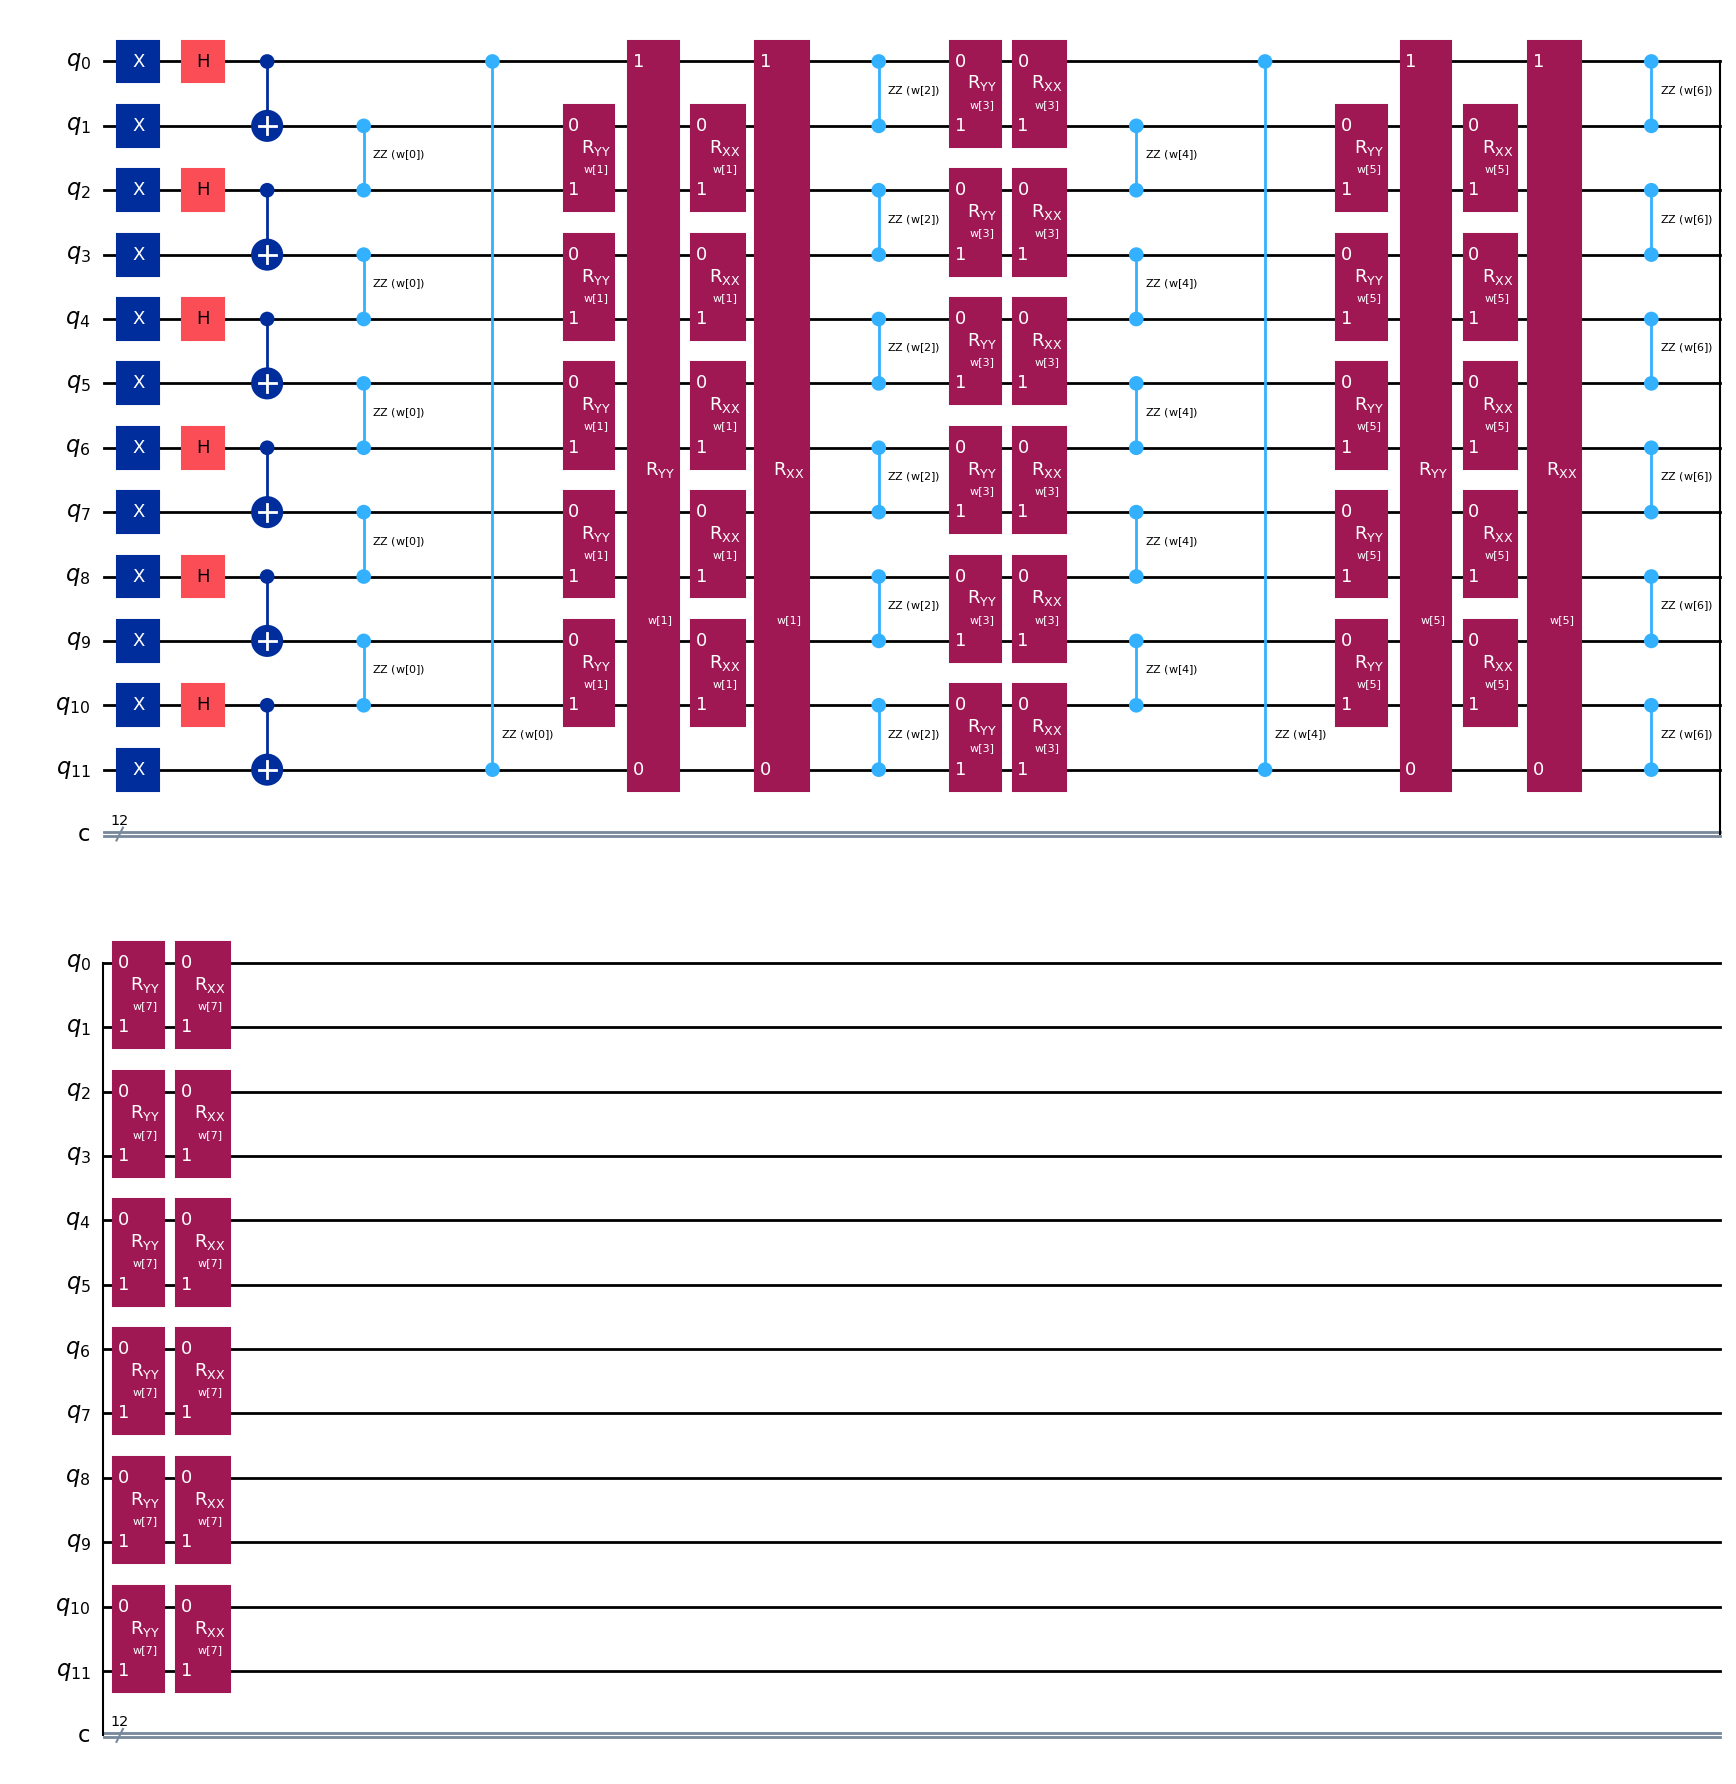

In [16]:
"""Circuit construction"""
layer = 2  # Define the number of layers in the quantum circuit

# This needs to be determined based on the circuit
num_p = layer * 4  # Calculate the number of parameters

weights = ParameterVector("w", num_p)  # Create a vector of parameters (parameters of the quantum circuit)

def circuit_QAOA_XXZ(weights):
    circ = QuantumCircuit(num_q, num_q)
    
    # Input layer to prepare Bell state -\psi
    for j in range(num_q):
        circ.x(j)  # Apply X gate to all qubits, initializing them from |0> to |1>.
    for j in range(int(num_q / 2)):
        # Then, for each pair of adjacent qubits (2j and 2j+1), apply H gate and CX (CNOT) gate to create Bell states.
        circ.h(2 * j)  # Apply Hadamard gate to each pair of qubits to create superposition states
        circ.cx(2 * j, 2 * j + 1)  # Create Bell state: Apply CNOT gate to each pair of qubits

    # QAOA Ansatz (variational layers)
    # Each layer consists of two parts: odd layers and even layers. The total number of layers is 'layer', with 2 sub-layers inside.
    for i in range(layer):
        ## Odd layers
        for j in range(int(num_q / 2)):
            circ.rzz(weights[4 * i], 2 * j + 1, (2 * j + 2) % num_q)  ## ZZ gates in odd sum
            # weights  [0]
        for j in range(int(num_q / 2)):
            circ.ryy(weights[4 * i + 1], 2 * j + 1, (2 * j + 2) % num_q)  ## YY gates in odd sum
            # weights  [1]
        for j in range(int(num_q / 2)):
            circ.rxx(weights[4 * i + 1], 2 * j + 1, (2 * j + 2) % num_q)  ## XX gates in odd sum
            # weights  [1]

        ## Even layers
        for j in range(int(num_q / 2)):
            circ.rzz(weights[4 * i + 2], 2 * j, 2 * j + 1)  ## ZZ gates in even sum
            # weights  [2]
        for j in range(int(num_q / 2)):
            circ.ryy(weights[4 * i + 3], 2 * j, 2 * j + 1)  ## YY gates in even sum
            # weights  [3]
        for j in range(int(num_q / 2)):
            circ.rxx(weights[4 * i + 3], 2 * j, 2 * j + 1)  ## XX gates in even sum
            # weights  [3]

    return circ 

qc = circuit_QAOA_XXZ(weights)
# print(qc)
qc.draw("mpl")


In [17]:
simulator = AerSimulator()


def expectation_loss(WEIGHTS):
    qc = circuit_QAOA_XXZ(WEIGHTS)
    qc.save_statevector()
    qc = transpile(qc, simulator)
    result = simulator.run(qc).result()
    state_vector = result.get_statevector(qc)
    psi = np.asarray(state_vector)
    # ==========================================================================
    Hpsi = Hmat.dot(psi)
    expectation = np.inner(np.conjugate(psi),Hpsi)
    return np.real(expectation)


In [18]:
# # File path for weights_dict
# weights_dict_file = f'XXZ_numq{num_q}_layer{layer}_Delta{Delta}_weights_dict.pkl'

# try:
#     # Try to load an existing weights_dict.pkl file
#     if os.path.exists(weights_dict_file):
#         with open(weights_dict_file, 'rb') as file:
#             weights_dict = pickle.load(file)
#         print("Successfully loaded weights_dict from weights_dict.pkl")
#     else:
#         raise FileNotFoundError

# except FileNotFoundError:
#     print("weights_dict.pkl not found. Generating weights_dict...")
    
weights_dict = {}

#################### Odd layers with RZZ gates
# omegas_1 = list(range(1, num_q // 2 + 1)) # Example: [1, 2]
# interp_nodes_1 = np.linspace(0, 2 * np.pi, 2 * len(omegas_1) + 1, endpoint=False)
# inverse_interp_matrix_1 = np.linalg.inv(interp_matrix(interp_nodes_1, omegas_1))

if num_q == 4:
    omegas = [2]
elif num_q == 5:
    omegas = list(range(1, 3))
elif num_q == 6:
    omegas = [2]
elif num_q == 7:
    omegas = list(range(1, 4))
elif num_q == 8:
    omegas = [2, 4]
elif num_q == 9:
    omegas = list(range(1, 5))
elif num_q == 10:
    omegas = [2, 4]
elif num_q == 11:
    omegas = list(range(1, 6))
elif num_q == 12:
    omegas = [2, 4, 6]
elif num_q == 13:
    omegas = list(range(1, 7))

omegas_1 = omegas
# opt_mse, interp_nodes_1, inverse_interp_matrix_1 = optimal_interp_points(omegas_1)
# print("Optimal MSE for omegas_1:", opt_mse)

#################### Even layers with RYY+RXX gates
# omegas_2 = list(range(1, (num_q // 2) * 2 + 1)) # Example: [1, 2, 3, 4]
# interp_nodes_2 = np.linspace(0, 2 * np.pi, 2 * len(omegas_2) + 1, endpoint=False)
# inverse_interp_matrix_2 = np.linalg.inv(interp_matrix(interp_nodes_2, omegas_2))

if num_q == 4:
    omegas = [2, 4]
elif num_q == 5:
    omegas = list(range(1, 5))
elif num_q == 6:
    omegas = [2, 4]
elif num_q == 7:
    omegas = list(range(1, 7))
elif num_q == 8:
    omegas = [2, 4, 6, 8]
elif num_q == 9:
    omegas = list(range(1, 9))
elif num_q == 10:
    omegas = [2, 4, 6, 8]
elif num_q == 11:
    omegas = list(range(1, 11))
elif num_q == 12:
    omegas = [2, 4, 6, 8, 10, 12]
elif num_q == 13:
    omegas = list(range(1, 13))

omegas_2 = omegas
# opt_mse, interp_nodes_2, inverse_interp_matrix_2 = optimal_interp_points(omegas_2)
# print("Optimal MSE for omegas_2:", opt_mse)

# Construct weights_dict
weights_dict = {}
for j in range(num_p): 
    if j % 2 == 0:  # Odd layers with RZZ gates
        weights_dict[f'weights_{j}'] = {
            'omegas': list(range(1, num_q // 2 + 1)),
            'scale_factor': 2.0,
            'interp_nodes': [],
            'inverse_interp_matrix': [],
        }
    elif j % 2 == 1:  # Even layers with RYY+RXX gates
        weights_dict[f'weights_{j}'] = {
            'omegas': list(range(1, (num_q // 2) * 2 + 1)),
            'scale_factor': 2.0,
            'interp_nodes': [],
            'inverse_interp_matrix': [],
        }
    
    # # Save weights_dict to a file
    # with open(weights_dict_file, 'wb') as file:
    #     pickle.dump(weights_dict, file)
    # print("Generated and saved weights_dict to weights_dict.pkl")

# Print example results
print(weights_dict['weights_0'])
print(weights_dict['weights_1'])
print(len(weights_dict))
print(num_q)

{'omegas': [1, 2, 3, 4, 5, 6], 'scale_factor': 2.0, 'interp_nodes': [], 'inverse_interp_matrix': []}
{'omegas': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 'scale_factor': 2.0, 'interp_nodes': [], 'inverse_interp_matrix': []}
8
12


In [ ]:
# Verify if the function can be accurately interpolated by trigonometric interpolation based on omegas

from check_utils import check_is_trigometric  # Assuming check_is_trigometric is defined in check_utils module
from check_utils import filter_omegas  # Assuming check_is_trigometric is defined in check_utils module

# Define random weights
weights = np.random.normal(0, 4 * np.pi**2, num_p)

# Loop over each weight index and check trigonometric interpolation

TRUE_OMEGAS= []
for j in range(num_p):
    # Circuit_HEA is simple and all Hermitian generators are Y.
    omegas = weights_dict[f'weights_{j}']['omegas']  # This needs to be determined based on the circuit (i.e., parameters to test interpolation)
    
    print('\n index to check = ', j)
    print('omegas = ', omegas)
    
    opt_interp_flag = False  # Flag to indicate if optimal interpolation should be used
    
    # Call the function to check if the objective function can be interpolated using trigonometric interpolation
    estimated_coefficients = check_is_trigometric(expectation_loss, j, omegas, weights, opt_interp_flag)
    
    true_oemgeas = filter_omegas(estimated_coefficients, omegas, threshold=1e-8)

    print('true_oemgeas = ', true_oemgeas)
    TRUE_OMEGAS.append(true_oemgeas)


 index to check =  0
omegas =  [1, 2, 3, 4, 5, 6]
Consistent results: 50/50
【All Passed】
Estimated coefficients:  [-9.95694112e-01  9.87082695e-13 -1.11480837e-13 -1.84650226e-01
  9.96201201e-01 -4.66064211e-13 -4.81370580e-13  1.45915835e-01
  6.06858096e-02 -4.87251406e-13 -3.80495162e-13  1.53307221e-13
 -1.49517186e-13]
true_oemgeas =  [2 4]

 index to check =  1
omegas =  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Consistent results: 50/50
【All Passed】
Estimated coefficients:  [-2.07565497e+00  6.48615018e-14 -9.37521581e-14  8.37300224e-01
  3.80182863e-01  4.59281996e-14  2.09807746e-13  5.86766957e-01
  1.05868234e-01 -1.00604938e-13 -4.14744022e-14  5.12138788e-02
  8.06898968e-02 -1.01355614e-14  5.73206518e-14 -1.45562736e-02
  3.98883459e-03 -7.72439755e-14 -1.35070221e-13  7.95951473e-14
 -9.74882754e-14  7.12201475e-14  3.89080144e-14 -3.04449935e-15
  3.53165147e-14]
true_oemgeas =  [2 4 6 8]

 index to check =  2
omegas =  [1, 2, 3, 4, 5, 6]
Consistent results: 50/50
【Al

In [22]:
for i in range(len(TRUE_OMEGAS)):
    # print('index to check = ', i)
    print(TRUE_OMEGAS[i])

[2 4]
[2 4 6 8]
[2 4]
[2 4 6 8]
[2]
[2 4]
[2]
[2 4]
